## Feature Transformation

To use PCA Algorithm for dimensionality reduction.
You have a dataset that includes measurements for different variables on wine
(alcohol, ash, magnesium, and so on). Apply PCA algorithm & transform this data
so that most variations in the measurements of the variables are captured by a small
number of principal components so that it is easier to distinguish between red and
white wine by inspecting these principal components.
Dataset Link: https://media.geeksforgeeks.org/wp-content/uploads/Wine.csv

## Principal Component Analysis

PCA, or `Principal Component Analysis`, is a dimensionality reduction technique widely used in data analysis and machine learning. It transforms a dataset with many variables into a smaller set of new variables, called principal components, which capture the most significant variations in the data. These principal components are orthogonal (uncorrelated) and ordered by the amount of variance they explain, making it easier to visualize, analyze, and preprocess data. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [22]:
df = pd.read_csv("Wine.csv")

## About Dataset

| **Feature Name**               | **Description**                                                       |
| ------------------------------ | --------------------------------------------------------------------- |
| `Alcohol`                      | Alcohol content of the wine                                           |
| `Malic_Acid`                   | Concentration of malic acid                                           |
| `Ash`                          | Amount of ash                                                         |
| `Ash_Alcanity`                 | Alkalinity of ash                                                     |
| `Magnesium`                    | Magnesium content                                                     |
| `Total_Phenols`                | Total phenol content                                                  |
| `Flavanoids`                   | Flavonoid content (a type of polyphenol compound)                     |
| `Nonflavanoid_Phenols`         | Non-flavonoid phenols content                                         |
| `Proanthocyanins`              | Proanthocyanin content (type of tannin/pigment)                       |
| `Color_Intensity`              | Intensity of the wine’s color                                         |
| `Hue`                          | Hue or shade of the wine color                                        |
| `OD280/OD315_of_Diluted_Wines` | Ratio of absorbance indicating wine quality                           |
| `Proline`                      | Proline amino acid level (linked to ripeness and sweetness of grapes) |
| `Customer_Segment`             | Target class label (1, 2, or 3 — representing different wine types)   |

In [23]:
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
 13  Customer_Segment      178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [25]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,1.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,1.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,1.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,2.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,3.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,3.000000


In [26]:
df.isnull().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
Customer_Segment        0
dtype: int64

In [27]:
df.Customer_Segment.unique()

array([1, 2, 3], dtype=int64)

## Implementing PCA

In [28]:
X = df.drop('Customer_Segment', axis=1)  # All features
y = df['Customer_Segment']  # Target class (Red/White/Other)

In [29]:
# Standardize the features (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_components=13 means you want to reduce your data to 13 principal components (new uncorrelated features), or keep the top 13 components that capture the most variance in the data.

In [34]:
#  PCA and keep all components for visualization
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Check explained variance
explained_variance = pca.explained_variance_ratio_
print("Explained Variance by Components:\n", explained_variance)

Explained Variance by Components:
 [0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


`Variance` is a statistical measure that quantifies the spread or dispersion of a set of data points around its mean (average) value. 

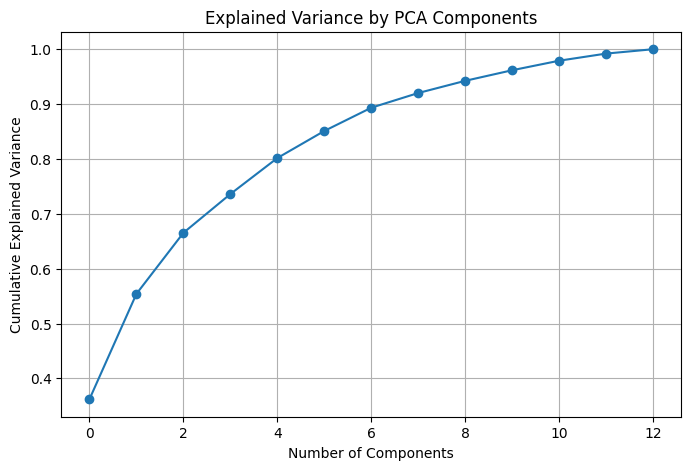

In [35]:
# Scree plot to visualize variance
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()

In [32]:
# Let's reduce to 2 components for visualization
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_scaled)

# Create DataFrame for plotting
pca_df = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
pca_df['Segment'] = y

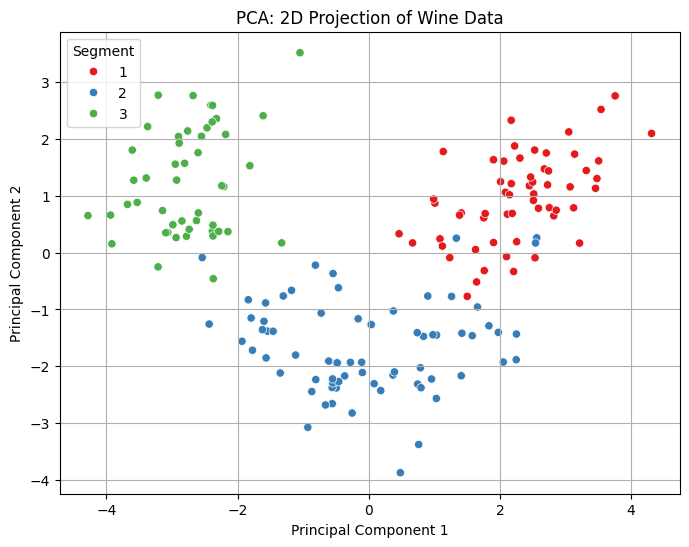

In [33]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Segment', palette='Set1')
plt.title('PCA: 2D Projection of Wine Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## Clasification using KNN

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [39]:
# 6. Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can tune 'k'
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [40]:
# 7. Make predictions
y_pred = knn.predict(X_test)

In [42]:
y_pred[:5]

array([1, 1, 3, 1, 2], dtype=int64)

In [44]:
y_test[:5]

19     1
45     1
140    3
30     1
67     2
Name: Customer_Segment, dtype: int64

In [45]:
accuracy_score(y_test, y_pred)

0.9444444444444444